# Fishbone Grating MPB 仿真后处理分析
本 Notebook 用于提取并分析 `.npz` 缓存数据，免去重复运行耗时的 MPB 3D 仿真。主要包含：
1. 数据加载
2. 查看完整能带图
3. 分析指定能带的群折射率 (ng)
4. 绘制特定 k 点的三维模场切片 (并叠加 epsilon 几何轮廓)

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 设置默认绘图风格
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

## 1. 导入仿真结果
从指定的输出文件夹中加载之前跑好的数据和模场缓存。

In [4]:
data_dir = "output"

# 加载基础能带数据
data_71nm = np.load(os.path.join(data_dir, 'yeven_71nm_data.npz'), allow_pickle=True)
data_140nm = np.load(os.path.join(data_dir, 'yeven_140nm_data.npz'), allow_pickle=True)

# 加载模场数据
modes_71nm = np.load(os.path.join(data_dir, 'yeven_71nm_modes_data.npz'), allow_pickle=True)
modes_140nm = np.load(os.path.join(data_dir, 'yeven_140nm_modes_data.npz'), allow_pickle=True)

print("✅ 所有数据加载完成！")

✅ 所有数据加载完成！


## 2. 查看所有能带图 (Band Diagram)
绘制完整的色散曲线，画出 SiO2 包层的光锥，并标出 1550 nm 目标波长线。

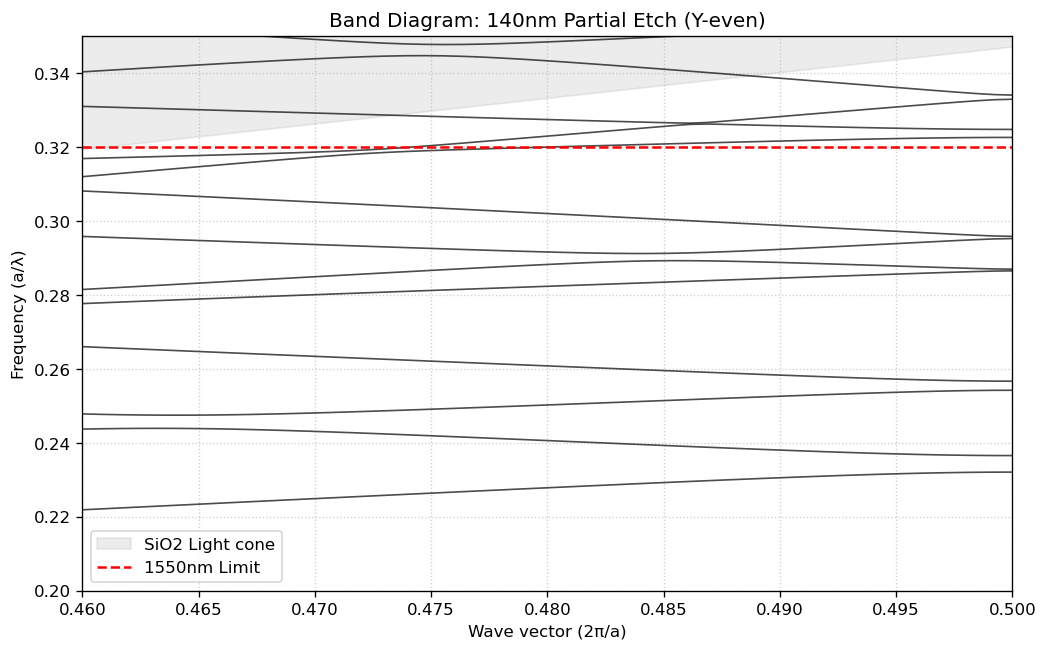

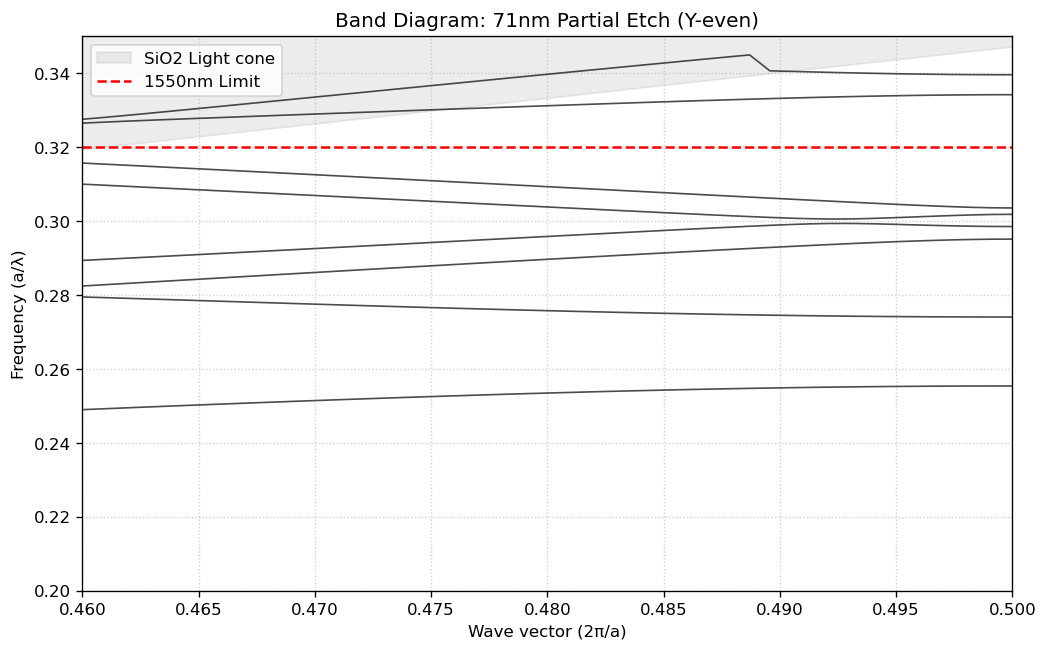

In [8]:
def plot_band_diagram(data_dict, title):
    k_x = data_dict['k_x']
    all_freqs = data_dict['all_freqs']
    a_nm = float(data_dict['params'].item()['a_nm'])
    
    f_lo, f_hi = 0.20, 0.35
    f_lc = k_x / 1.44  # N_SIO2 = 1.44
    f_1550 = a_nm / 1550.0

    plt.figure()
    plt.fill_between(k_x, np.maximum(f_lc, f_lo), f_hi, alpha=0.15, color='gray', label='SiO2 Light cone')
    
    num_bands = all_freqs.shape[1]
    for b in range(num_bands):
        plt.plot(k_x, all_freqs[:, b], 'k-', lw=1.0, alpha=0.7)
        
    plt.axhline(f_1550, color='red', ls='--', lw=1.5, label='1550nm Limit')
    
    plt.xlabel('Wave vector (2π/a)')
    plt.ylabel('Frequency (a/λ)')
    plt.title(title)
    plt.xlim(k_x[0], k_x[-1])
    plt.ylim(f_lo, f_hi)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_band_diagram(data_140nm, 'Band Diagram: 140nm Partial Etch (Y-even)')
plot_band_diagram(data_71nm, 'Band Diagram: 71nm Partial Etch (Y-even)')

## 3. 画出指定目标能带的群折射率 ($n_g$)

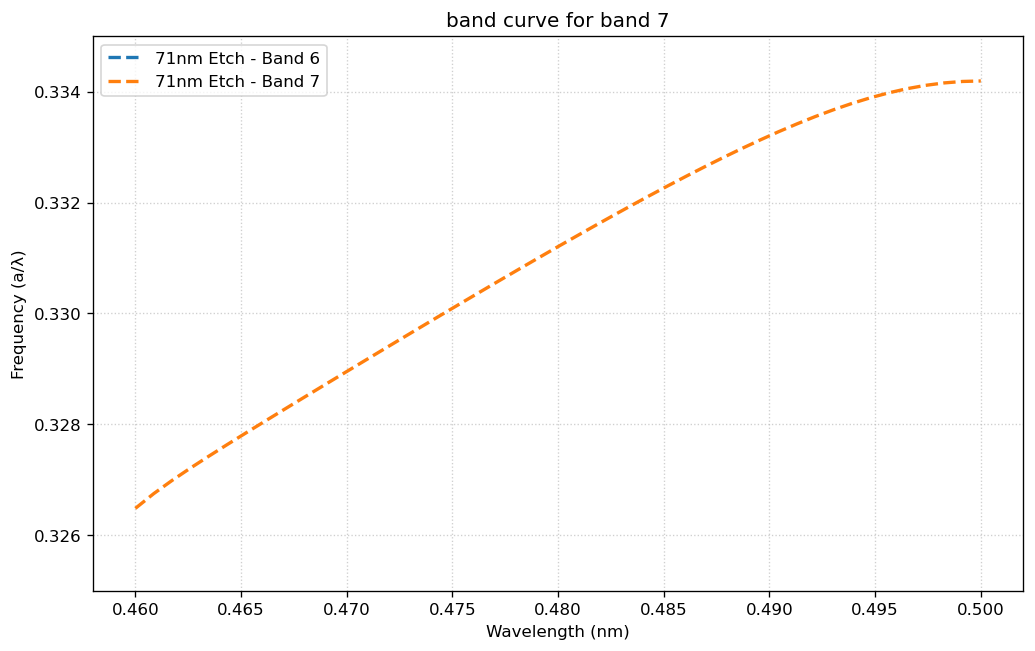

In [8]:
import matplotlib.pyplot as plt
def plot_band_comparison(y_min=None, y_max=None):
    plt.figure()
    
    
    # 71nm Etch
    k_71 = data_71nm['k_x']
    a_71 = float(data_71nm['params'].item()['a_nm'])
    freqs_71 = data_71nm['all_freqs']
    target_71 = modes_71nm['target_bands']
    
    for ib, band_idx in enumerate(target_71):
        freq_curve = freqs_71[:, band_idx - 1] 
       
        
        wl_nm = a_71 / freq_curve
        plt.plot(k_71, freq_curve, '--', lw=2.0, label=f'71nm Etch - Band {band_idx}')
        
    #plt.axvline(1550.0, color='gray', linestyle=':', label='1550nm')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Frequency (a/λ)')
    plt.title(f'band curve for band {band_idx}')
    #plt.xlim(1500, 1600)
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

#plot_band_comparison()
plot_band_comparison(y_min=0.325, y_max=0.335)

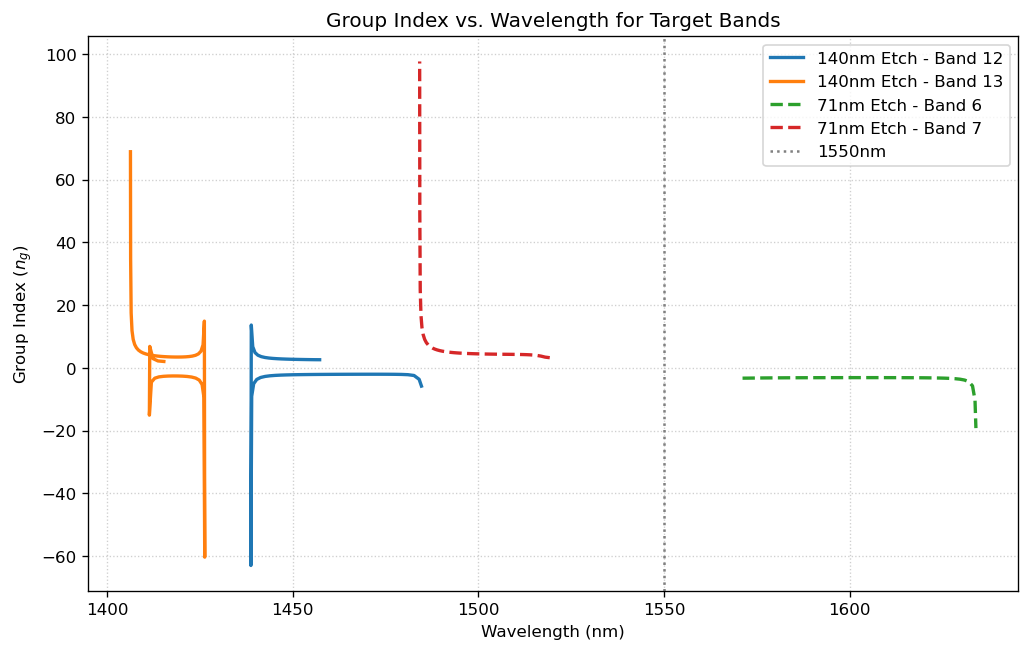

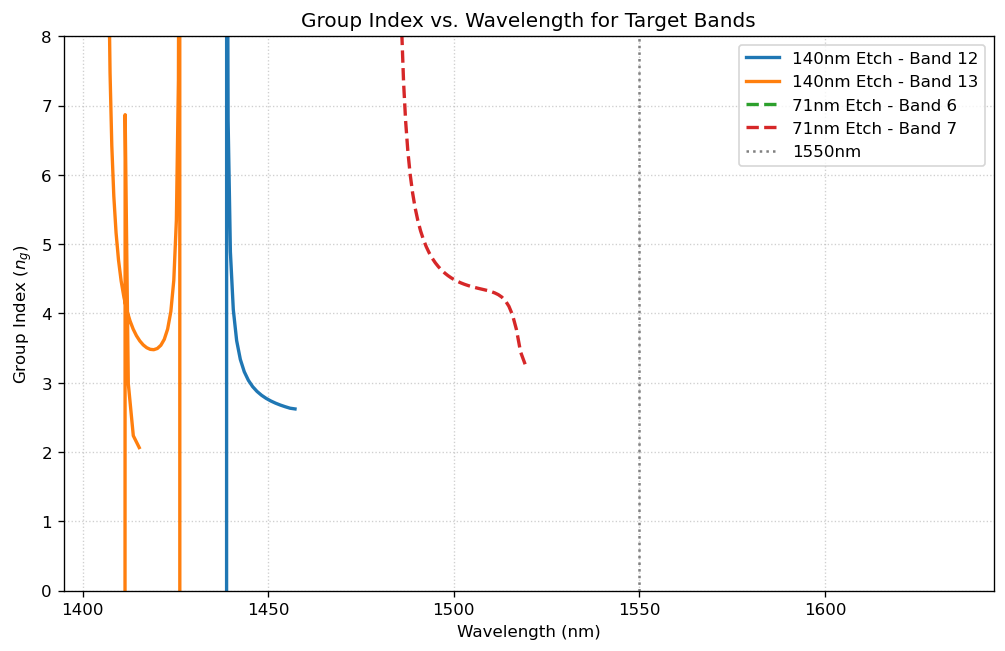

In [12]:
def plot_ng_comparison(y_min=None, y_max=None):
    plt.figure()
    
    # 140nm Etch
    k_140 = data_140nm['k_x']
    a_140 = float(data_140nm['params'].item()['a_nm'])
    freqs_140 = data_140nm['all_freqs']
    target_140 = [12,13]#modes_140nm['target_bands']
    
    for ib, band_idx in enumerate(target_140):
        # 频率对应 Python 列索引通常比能带号少 1
        freq_curve = freqs_140[:, band_idx - 1] 
        dk = np.gradient(k_140)
        df = np.gradient(freq_curve)
        vg = df / dk
        ng = np.zeros_like(vg)
        nonzero = np.abs(vg) > 1e-10
        ng[nonzero] = 1.0 / vg[nonzero]
        wl_nm = a_140 / freq_curve
        plt.plot(wl_nm, ng, '-', lw=2.0, label=f'140nm Etch - Band {band_idx}')

    # 71nm Etch
    k_71 = data_71nm['k_x']
    a_71 = float(data_71nm['params'].item()['a_nm'])
    freqs_71 = data_71nm['all_freqs']
    target_71 = modes_71nm['target_bands']
    
    for ib, band_idx in enumerate(target_71):
        freq_curve = freqs_71[:, band_idx - 1] 
        dk = np.gradient(k_71)
        df = np.gradient(freq_curve)
        vg = df / dk
        ng = np.zeros_like(vg)
        nonzero = np.abs(vg) > 1e-10
        ng[nonzero] = 1.0 / vg[nonzero]
        wl_nm = a_71 / freq_curve
        plt.plot(wl_nm, ng, '--', lw=2.0, label=f'71nm Etch - Band {band_idx}')
        
    plt.axvline(1550.0, color='gray', linestyle=':', label='1550nm')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Group Index ($n_g$)')
    plt.title('Group Index vs. Wavelength for Target Bands')
    #plt.xlim(1500, 1600)
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_ng_comparison()
plot_ng_comparison(y_min=0, y_max=8)

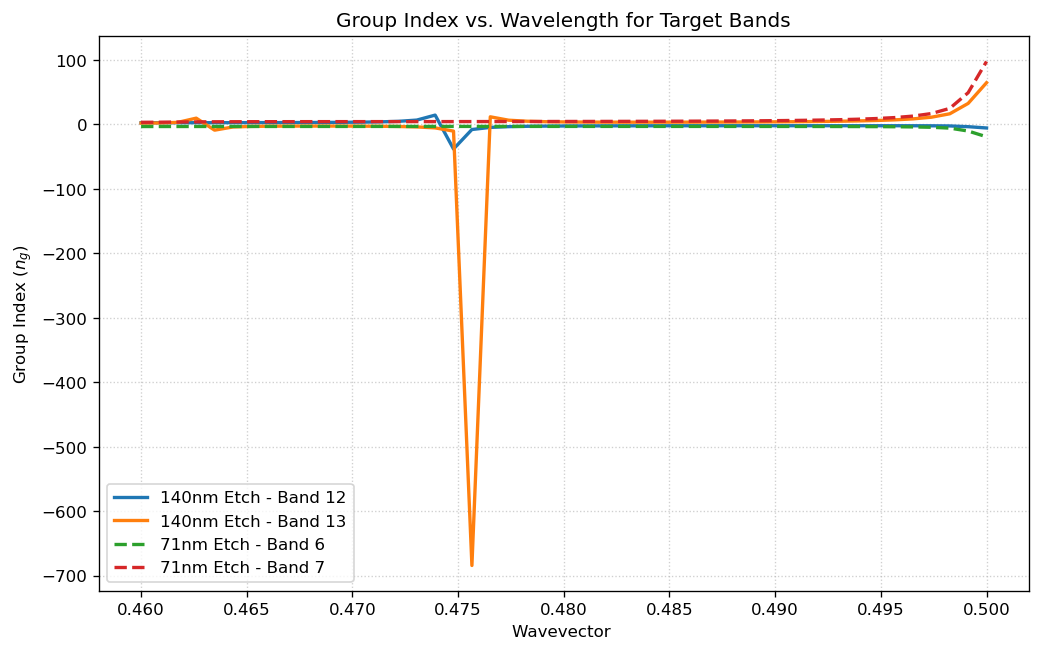

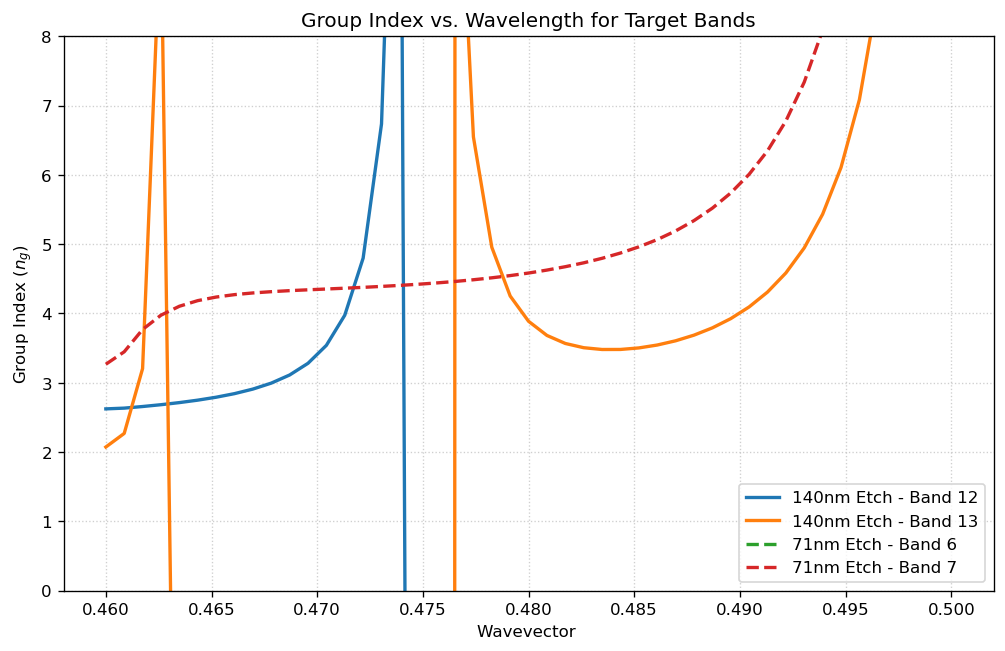

In [11]:
def plot_ng_comparison(y_min=None, y_max=None):
    plt.figure()
    
    # 140nm Etch
    k_140 = data_140nm['k_x']
    a_140 = float(data_140nm['params'].item()['a_nm'])
    freqs_140 = data_140nm['all_freqs']
    target_140 = [12,13]#modes_140nm['target_bands']
    
    for ib, band_idx in enumerate(target_140):
        # 频率对应 Python 列索引通常比能带号少 1
        freq_curve = freqs_140[:, band_idx - 1] 
        dk = np.gradient(k_140)
        df = np.gradient(freq_curve)
        vg = df / dk
        ng = np.zeros_like(vg)
        nonzero = np.abs(vg) > 1e-10
        ng[nonzero] = 1.0 / vg[nonzero]
        wl_nm = a_140 / freq_curve
        plt.plot(k_140, ng, '-', lw=2.0, label=f'140nm Etch - Band {band_idx}')

    # 71nm Etch
    k_71 = data_71nm['k_x']
    a_71 = float(data_71nm['params'].item()['a_nm'])
    freqs_71 = data_71nm['all_freqs']
    target_71 = modes_71nm['target_bands']
    
    for ib, band_idx in enumerate(target_71):
        freq_curve = freqs_71[:, band_idx - 1] 
        dk = np.gradient(k_71)
        df = np.gradient(freq_curve)
        vg = df / dk
        ng = np.zeros_like(vg)
        nonzero = np.abs(vg) > 1e-10
        ng[nonzero] = 1.0 / vg[nonzero]
        wl_nm = a_71 / freq_curve
        plt.plot(k_71, ng, '--', lw=2.0, label=f'71nm Etch - Band {band_idx}')
        
    #plt.axvline(1550.0, color='gray', linestyle=':', label='1550nm')
    plt.xlabel('Wavevector ')
    plt.ylabel('Group Index ($n_g$)')
    plt.title('Group Index vs. Wavelength for Target Bands')
    #plt.xlim(1500, 1600)
    plt.ylim(y_min, y_max)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_ng_comparison()
plot_ng_comparison(y_min=0, y_max=8)

In [13]:
lambda_1550 = 1550.0
f = 0.33
a = lambda_1550 * f
print(f"Calculated lattice constant a for 1550nm with f={f}: {a} nm")

Calculated lattice constant a for 1550nm with f=0.33: 511.5 nm


## 4. 画出指定带和k点的模场并且叠加 epsilon 结构轮廓

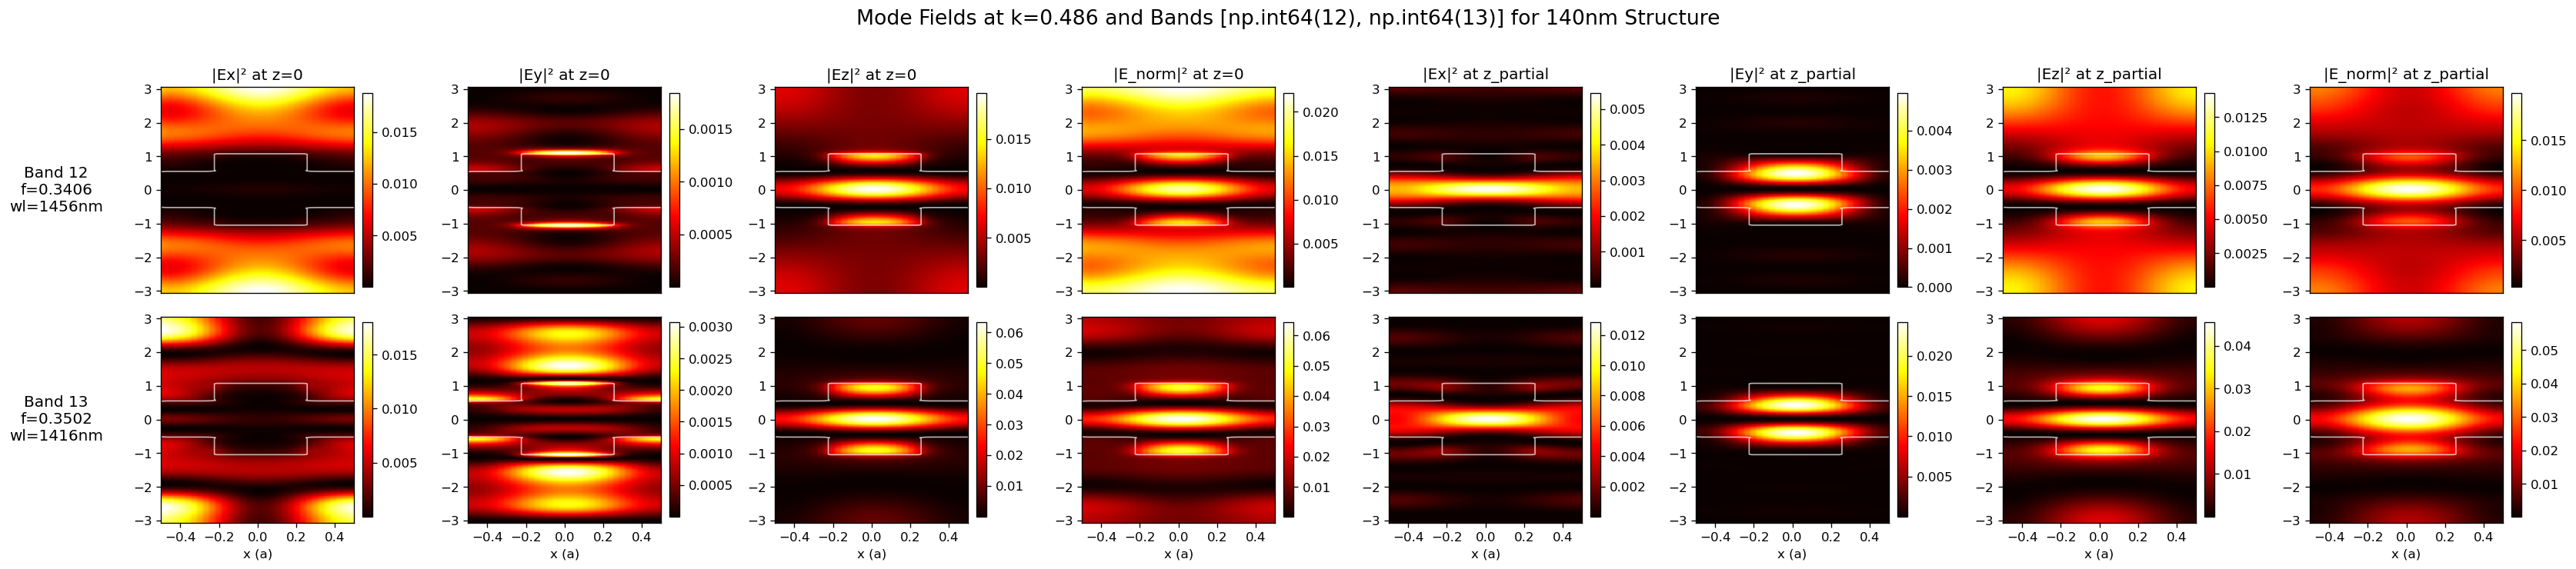

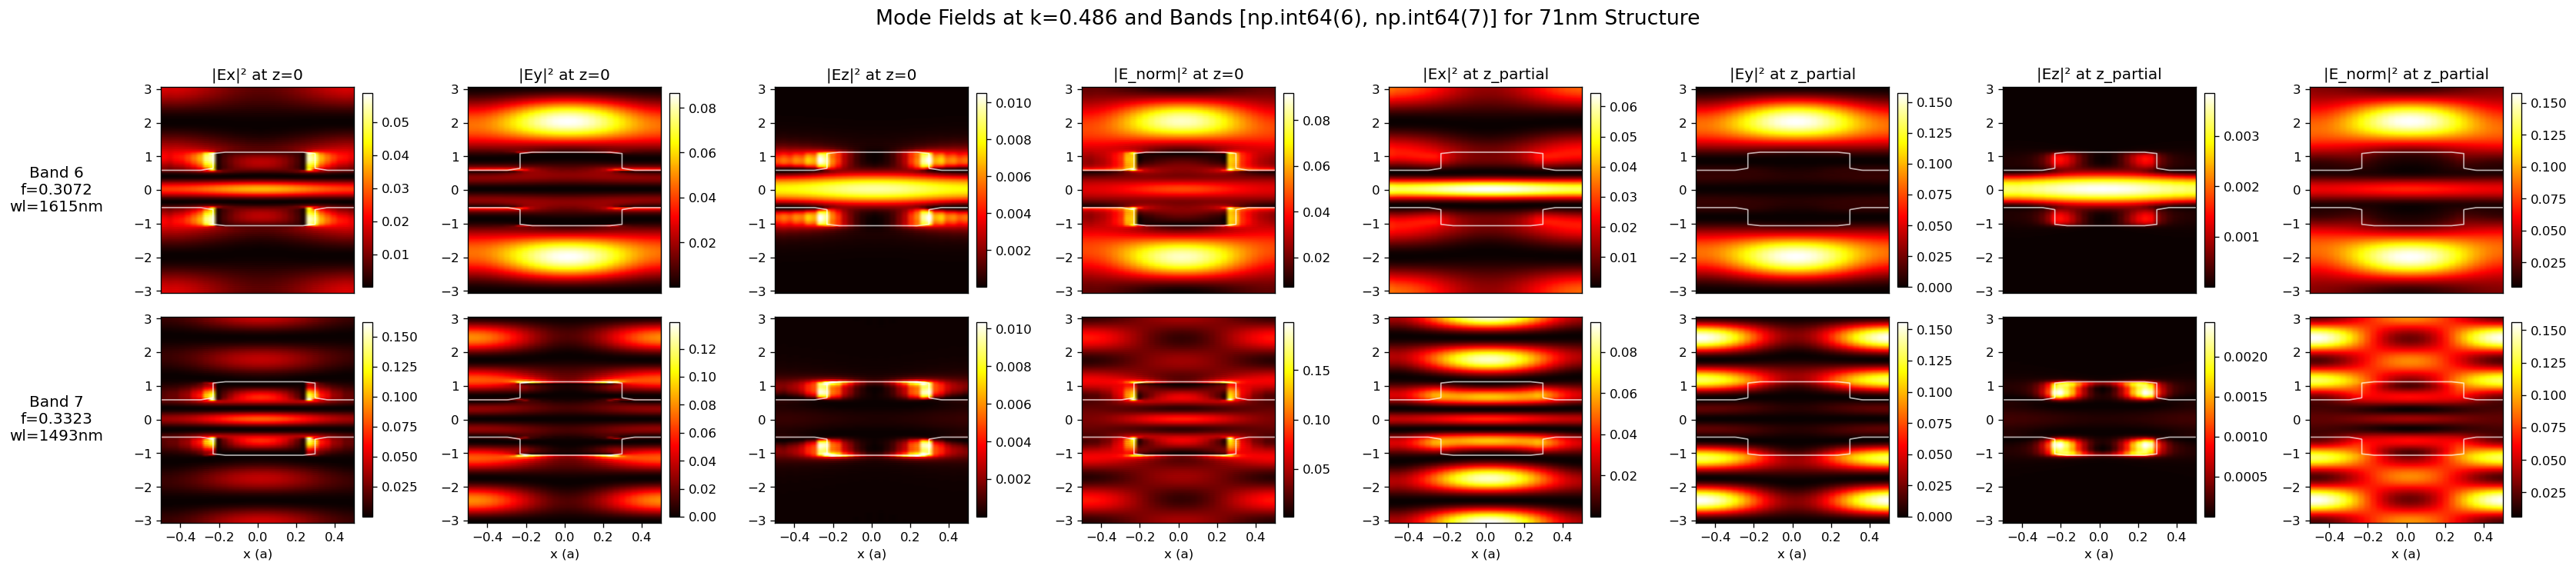

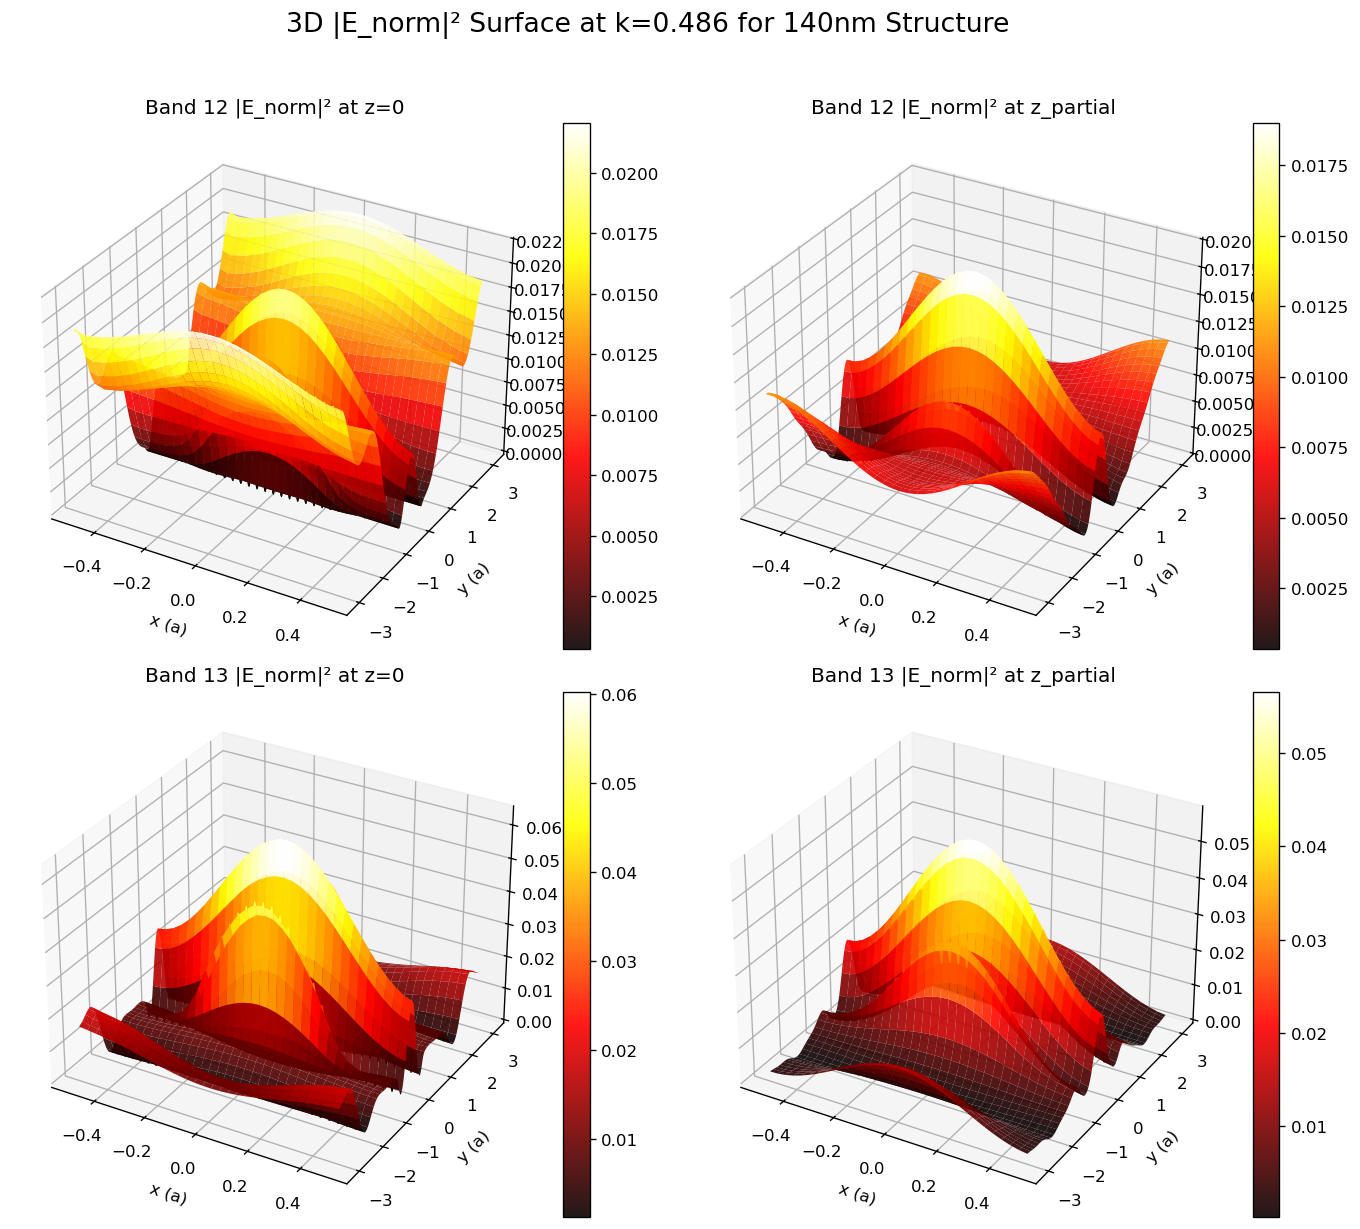

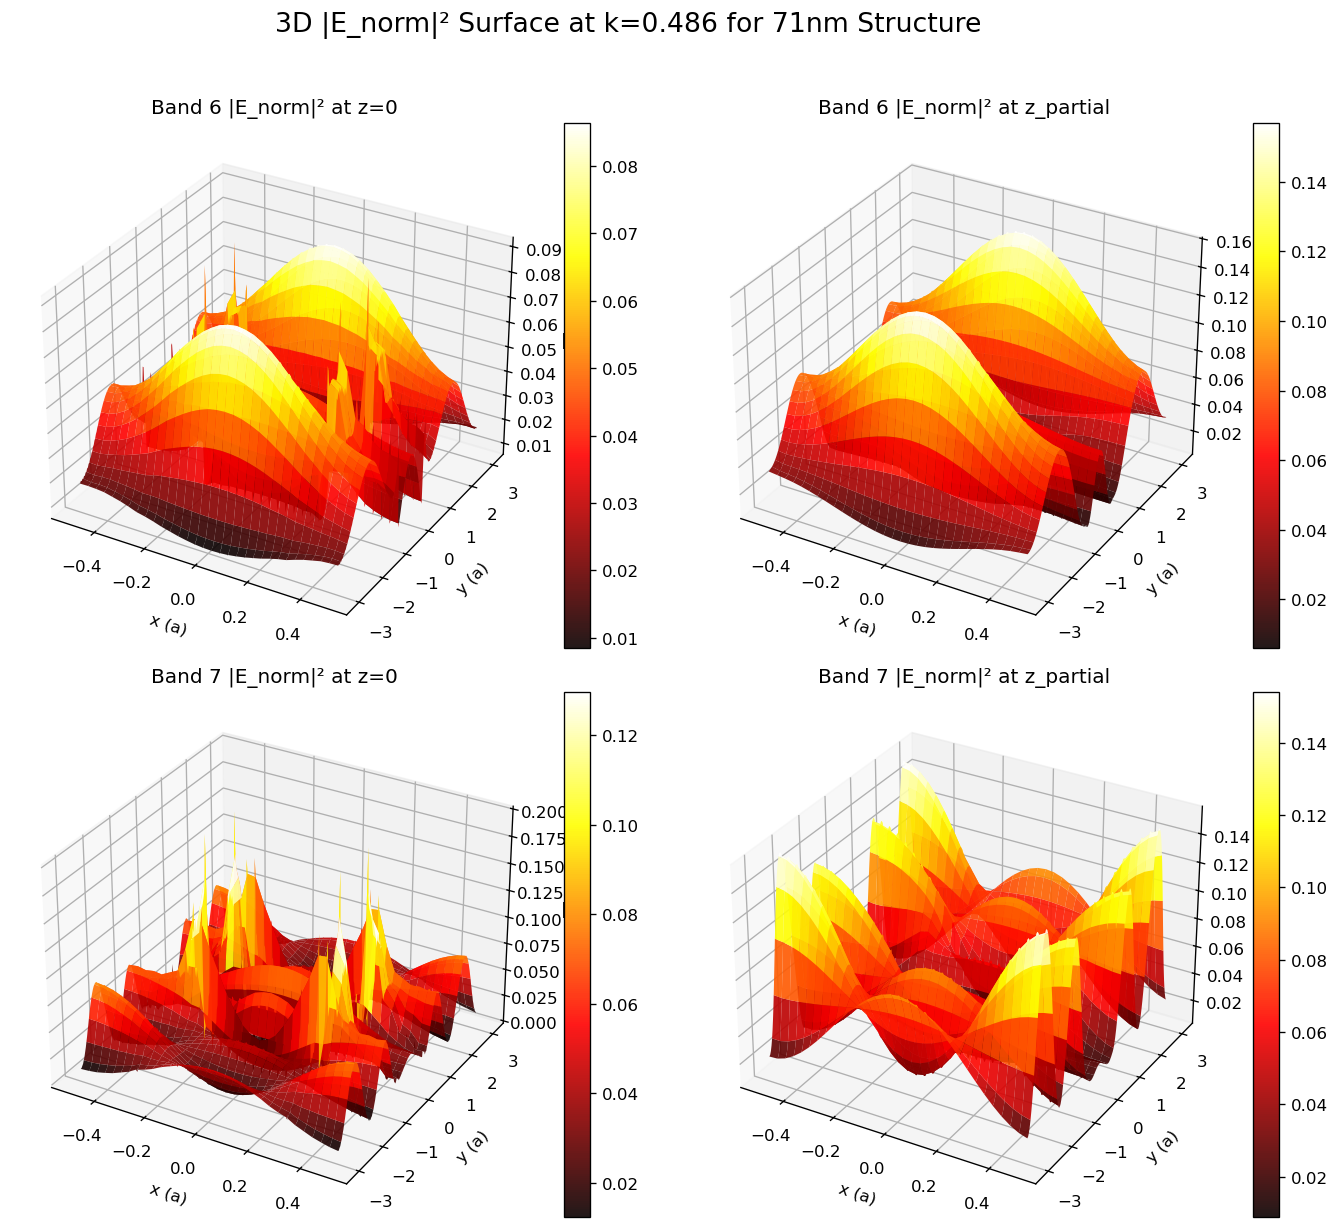

In [14]:
def plot_mode_fields_with_epsilon(base_data, modes_data, k_val, name="140nm", plot_enorm=True):
    eps = base_data['epsilon']
    sy = float(modes_data['sy'])
    sz = float(modes_data['sz'])
    a_nm = float(modes_data['a_nm'])
    target_bands = list(modes_data['target_bands'])
    
    t_slab = 220.0 / a_nm
    t_partial = (71.0 if name == "71nm" else 140.0) / a_nm
    z_val_partial = -t_slab/2.0 + t_partial/2.0
    
    nz_total = eps.shape[2]
    z_rib_idx = int(round(((0.9 * t_slab / 2.0) + sz/2.0) / sz * nz_total))
    eps_rib_structure = eps[:, :, z_rib_idx]
    
    efields = modes_data[f'k_{k_val:.3f}_efields']
    freqs = modes_data[f'k_{k_val:.3f}_freqs']
    nb = len(efields)
    
    cols_per_cut = 4 if plot_enorm else 3
    total_cols = 2 * cols_per_cut
    
    fig, axes = plt.subplots(nb, total_cols, figsize=(3.5 * total_cols, 3 * nb))
    if nb == 1: axes = axes[np.newaxis, :]
        
    extent_xy = [-0.5, 0.5, -sy/2, sy/2]

    for ib in range(nb):
        ef = efields[ib]
        f_val = freqs[ib]
        band_index = target_bands[ib]
        wl = a_nm / f_val if f_val > 0 else 0
        
        nx, ny, nz = ef.shape[:3]
        z_0_idx = nz // 2
        z_p_idx = int(round((z_val_partial + sz/2.0) / sz * nz))
        
        for cut_idx, (z_idx, label_suffix) in enumerate([(z_0_idx, "z=0"), (z_p_idx, "z_partial")]):
            for ic in range(cols_per_cut):
                ax_idx = cut_idx * cols_per_cut + ic
                ax = axes[ib, ax_idx]
                
                if ic < 3:
                    field_slice = np.abs(ef[:, :, z_idx, ic])**2
                    comp_name = ['Ex', 'Ey', 'Ez'][ic]
                else:
                    field_slice = np.sum(np.abs(ef[:, :, z_idx, :])**2, axis=-1)
                    comp_name = 'E_norm'
                    
                im = ax.imshow(field_slice.T, origin='lower', cmap='hot', aspect='auto', extent=extent_xy)
                ax.contour(eps_rib_structure.T, levels=[5.0], colors='w', linewidths=1.0, alpha=0.7, extent=extent_xy)
                
                if ax_idx == 0:
                    ax.set_ylabel(f'Band {band_index}\nf={f_val:.4f}\nwl={wl:.0f}nm', 
                                  fontsize=12, rotation=0, labelpad=60, va='center')
                if ib == 0:
                    ax.set_title(f'|{comp_name}|² at {label_suffix}')
                if ib == nb - 1:
                    ax.set_xlabel('x (a)')
                else:
                    ax.set_xticks([])
                    
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f"Mode Fields at k={k_val:.3f} and Bands {target_bands} for {name} Structure", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_enorm_3d_surface(modes_data, k_val, name="140nm"):
    sy = float(modes_data['sy'])
    sz = float(modes_data['sz'])
    a_nm = float(modes_data['a_nm'])
    target_bands = list(modes_data['target_bands'])
    
    t_slab = 220.0 / a_nm
    t_partial = (71.0 if name == "71nm" else 140.0) / a_nm
    z_val_partial = -t_slab/2.0 + t_partial/2.0
    
    efields = modes_data[f'k_{k_val:.3f}_efields']
    freqs = modes_data[f'k_{k_val:.3f}_freqs']
    nb = len(efields)
    
    fig = plt.figure(figsize=(12, 5 * nb))
    
    for ib in range(nb):
        ef = efields[ib]
        band_index = target_bands[ib]
        
        nx, ny, nz = ef.shape[:3]
        z_0_idx = nz // 2
        z_p_idx = int(round((z_val_partial + sz/2.0) / sz * nz))
        
        x = np.linspace(-0.5, 0.5, nx)
        y = np.linspace(-sy/2, sy/2, ny)
        X, Y = np.meshgrid(x, y, indexing='ij')
        
        for cut_idx, (z_idx, label_suffix) in enumerate([(z_0_idx, "z=0"), (z_p_idx, "z_partial")]):
            ax = fig.add_subplot(nb, 2, ib * 2 + cut_idx + 1, projection='3d')
            
            enorm_slice = np.sum(np.abs(ef[:, :, z_idx, :])**2, axis=-1)
            
            surf = ax.plot_surface(X, Y, enorm_slice, cmap='hot', edgecolor='none', alpha=0.9)
            ax.set_title(f'Band {band_index} |E_norm|² at {label_suffix}')
            ax.set_xlabel('x (a)')
            ax.set_ylabel('y (a)')
            ax.set_zlabel('|E|²')
            fig.colorbar(surf, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f"3D |E_norm|² Surface at k={k_val:.3f} for {name} Structure", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 画出指定 k 点的模场 (并包含 E_norm 分量)
plot_mode_fields_with_epsilon(data_140nm, modes_140nm, k_val=0.486, name="140nm", plot_enorm=True)
plot_mode_fields_with_epsilon(data_71nm, modes_71nm, k_val=0.486, name="71nm", plot_enorm=True)

# 画出指定 k 点的 3D E_norm 曲面图
plot_enorm_3d_surface(modes_140nm, k_val=0.486, name="140nm")
plot_enorm_3d_surface(modes_71nm, k_val=0.486, name="71nm")